# Retail Sales Forecasting

This notebook presents a complete data science understanding. The project focuses on forecasting weekly sales for a retail chain using historical sales data, store characteristics, and external factors.

## Problem Definition & Business Understanding

- **Objective:** Forecast weekly sales and understand key drivers (e.g., markdown promotions, holidays, economic factors) affecting sales performance.
- **Key Questions:**
  - What factors (store type, markdowns, holidays, economic indicators) drive sales?
  - How do promotional markdowns impact weekly sales?
  - Can we predict future sales accurately using historical data?
- **Success Metrics:** RMSE, MAE, R², and actionable insights for decision making.

### Import necessary Libraries

In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import LabelEncoder 
 
import scipy.stats as stats 

from sklearn.preprocessing import LabelEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings 
warnings.filterwarnings('ignore') 

## Data Integration

We have three datasets:

1. **features.csv**: Contains environmental and economic data (Temperature, Fuel_Price, CPI, Unemployment, MarkDowns, and IsHoliday).
2. **train.csv**: Contains weekly sales data (Store, Dept, Date, Weekly_Sales, IsHoliday).
3. **stores.csv**: Contains store characteristics (Store, Type, Size).

The datasets are merged using common keys (Store) to produce a final dataset for analysis. In this notebook, we assume the merged dataset is available as `df`.

In [5]:
features = pd.read_csv("features.csv.xls")

In [6]:
features.shape

(8190, 12)

**In Features has 8190 rows and 12 columns**

In [7]:
stores = pd.read_csv("stores.csv.xls")

In [8]:
stores.shape

(45, 3)

**In Store has 45 rows and 3 columns**

In [9]:
train = pd.read_csv("train.csv.xls")

In [10]:
train.shape

(421570, 5)

**In train has 421570 rows and 5 columns**

In [11]:
# Merge train with features on 'Store'
df = pd.merge(train, features, how="inner")

In [12]:
# Merge the result with stores on 'Store'
df = pd.merge(df, stores, on="Store", how="inner")

In [13]:
df.shape

(421570, 16)

**df DataFrame has 421570 and 16 rows in initial phase**

In [14]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


**<pre>Bool Datatype: IsHoliday
Object Dataype: Type
Date type: Date 
Nulls: All MarkDown</pre>**

## Data Cleaning & Preprocessing

- **Convert data types** (e.g., ensure the Date column is datetime).
- **Check for missing values** and handle them appropriately (e.g., fill missing markdowns with 0 if no discount was applied).

In [16]:
# Convert the Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [17]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

**Most missing values are likely in MarkDown columns.**

In [18]:
df[['MarkDown1', 'MarkDown2','MarkDown3','MarkDown4','MarkDown5']].isnull().sum().mean()

np.float64(284486.2)

**Around 284486 Weeks are not any MarkDown scheme is apply**

In [19]:
# fill the nulls whit 0
df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']] = df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].fillna(0)

In [20]:
df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

In [21]:
df = df.loc[df['Weekly_Sales'] > 0]

## Exploratory Data Analysis (EDA)
We perform univariate, bivariate, and multivariate analyses along with computing central tendency, dispersion, skewness, kurtosis, covariance, and correlation.

In [22]:
num_columns_means = df.select_dtypes(include=np.number).mean()
num_columns_means

Store               22.195611
Dept                44.241309
Weekly_Sales     16033.114591
Temperature         60.090599
Fuel_Price           3.360890
MarkDown1         2590.323565
MarkDown2          878.905242
MarkDown3          468.845949
MarkDown4         1083.534361
MarkDown5         1662.805002
CPI                171.212496
Unemployment         7.960000
Size            136749.732787
dtype: float64

In [23]:
num_columns_median = df.select_dtypes(include=np.number).median()
num_columns_median

Store               22.000000
Dept                37.000000
Weekly_Sales      7661.700000
Temperature         62.090000
Fuel_Price           3.452000
MarkDown1            0.000000
MarkDown2            0.000000
MarkDown3            0.000000
MarkDown4            0.000000
MarkDown5            0.000000
CPI                182.350989
Unemployment         7.866000
Size            140167.000000
dtype: float64

In [24]:
mode_values = df.mode().iloc[0]
mode_values

Store                          13.0
Dept                              1
Date            2011-12-23 00:00:00
Weekly_Sales                   10.0
IsHoliday                     False
Temperature                   50.43
Fuel_Price                    3.638
MarkDown1                       0.0
MarkDown2                       0.0
MarkDown3                       0.0
MarkDown4                       0.0
MarkDown5                       0.0
CPI                      129.855533
Unemployment                  8.099
Type                              A
Size                        39690.0
Name: 0, dtype: object

In [25]:
df.drop(['Date','Type'], axis=1).skew()

Store            0.077947
Dept             0.359016
Weekly_Sales     3.258942
IsHoliday        3.360255
Temperature     -0.321295
Fuel_Price      -0.104678
MarkDown1        4.730933
MarkDown2       10.649277
MarkDown3       14.908890
MarkDown4        8.075125
MarkDown5        9.952112
CPI              0.084673
Unemployment     1.183789
Size            -0.326689
dtype: float64

In [26]:
df.drop(['Date','Type'], axis=1).kurt()

Store            -1.146698
Dept             -1.216644
Weekly_Sales     21.460793
IsHoliday         9.291355
Temperature      -0.636128
Fuel_Price       -1.185445
MarkDown1        34.912307
MarkDown2       145.568291
MarkDown3       247.647517
MarkDown4        86.188903
MarkDown5       183.080984
CPI              -1.829848
Unemployment      2.729259
Size             -1.206400
dtype: float64

### Univariate Analysis

In [27]:
numerical_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

In [28]:
sample_size = 10000  # Adjust as needed
df_sampled = df.sample(n=min(sample_size, len(df)), random_state=42) # Ensure you don't sample more than the total rows
df_sampled

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
49544,6,6,2010-11-12,9971.58,False,62.11,2.728,0.00,0.00,0.00,0.00,0.00,213.526801,7.007,A,202505
87526,10,1,2010-02-19,49748.33,False,58.22,2.915,0.00,0.00,0.00,0.00,0.00,126.526286,9.765,B,126512
295158,31,11,2010-07-23,11979.60,False,87.17,2.608,0.00,0.00,0.00,0.00,0.00,210.892132,8.099,A,203750
164171,17,56,2012-04-27,7491.43,False,59.11,3.842,1832.86,0.00,1.62,8.94,2211.39,131.126667,6.235,B,93188
62726,7,29,2010-03-05,1187.00,False,35.86,2.620,0.00,0.00,0.00,0.00,0.00,189.669505,9.014,B,70713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358776,38,74,2012-07-20,637.22,False,85.53,3.726,75.04,0.00,0.19,0.00,1281.95,130.701290,10.926,C,39690
347694,37,9,2011-01-14,55.17,False,42.87,2.983,0.00,0.00,0.00,0.00,0.00,210.237973,8.395,C,39910
315095,33,9,2010-08-13,2.88,False,95.57,3.049,0.00,0.00,0.00,0.00,0.00,126.064000,9.495,A,39690
57521,6,85,2012-08-31,1642.29,False,83.58,3.638,21801.35,111.57,16.74,15675.98,4002.59,223.921012,5.668,A,202505


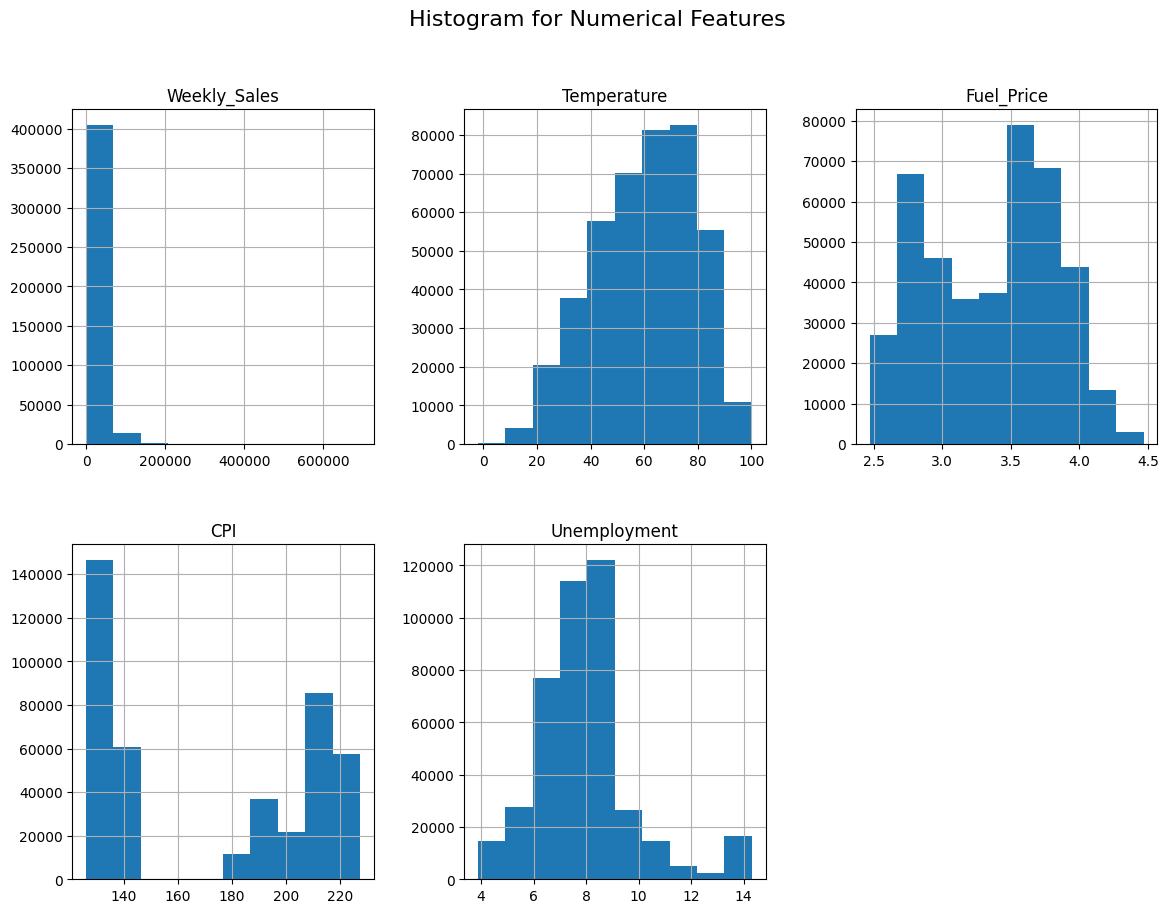

In [29]:
# Histograms for numerical features
df[numerical_cols].hist(figsize=(14,10), layout=(2, 3))
plt.suptitle("Histogram for Numerical Features", fontsize=16)
plt.show()


- **Weekly Sales is right-skewed.**

- **CPI and Unemployment have visible spread differences.**

- **Fuel price and temperature are centered normally.**

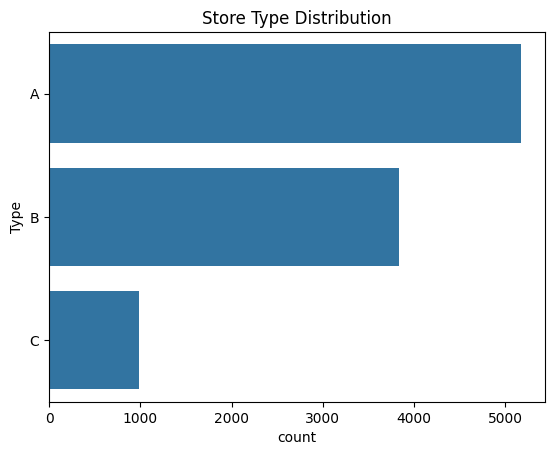

In [30]:
sns.countplot(df_sampled['Type'])
plt.title("Store Type Distribution")
plt.show()


- Type A stores dominate in number.

### Bivariate Analysis

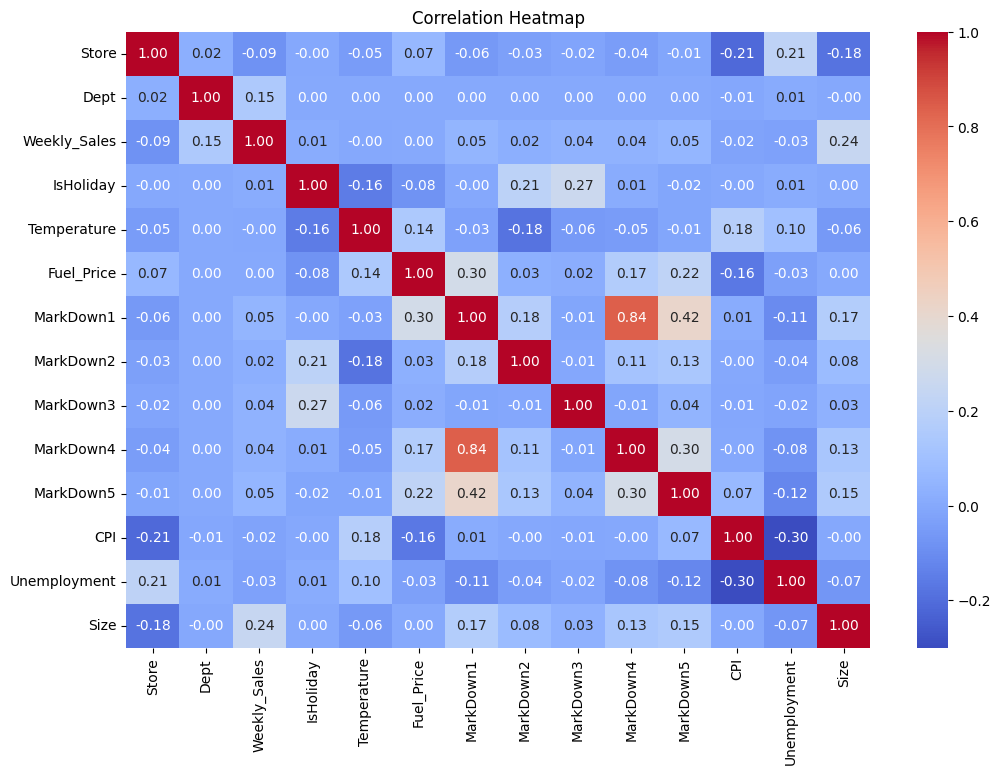

In [31]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop(['Date','Type'], axis=1).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


- Weekly_Sales has positive correlation with Size, MarkDown features.

- Weak negative correlation with Unemployment and CPI.

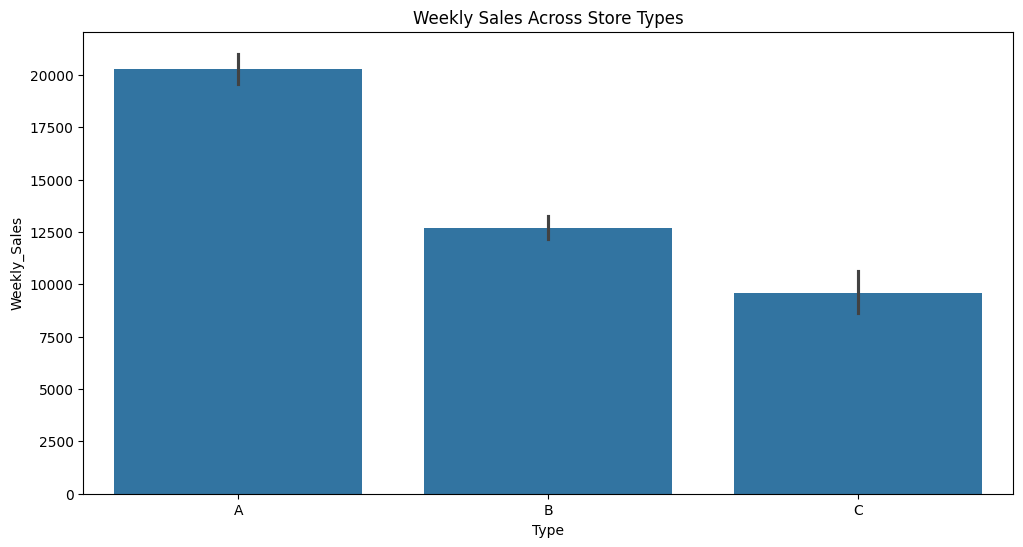

In [32]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Type', y='Weekly_Sales', data=df_sampled)
plt.title("Weekly Sales Across Store Types")
plt.show()


- **Type A stores tend to have higher weekly sales, possibly due to larger size.**

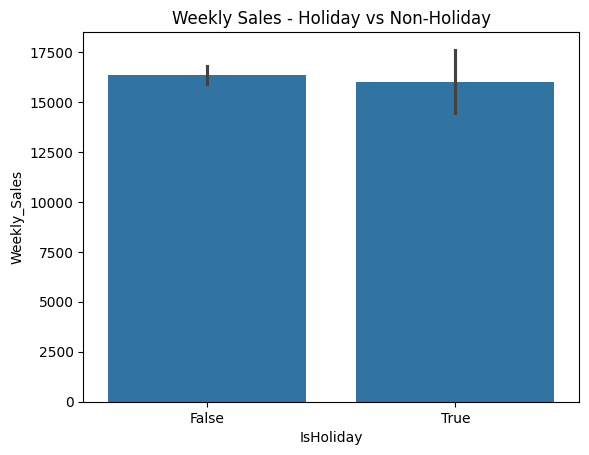

In [33]:
sns.barplot(x='IsHoliday', y='Weekly_Sales', data=df_sampled)
plt.title("Weekly Sales - Holiday vs Non-Holiday")
plt.show()


- Sales not increase during holidays — valuable for planning inventory.

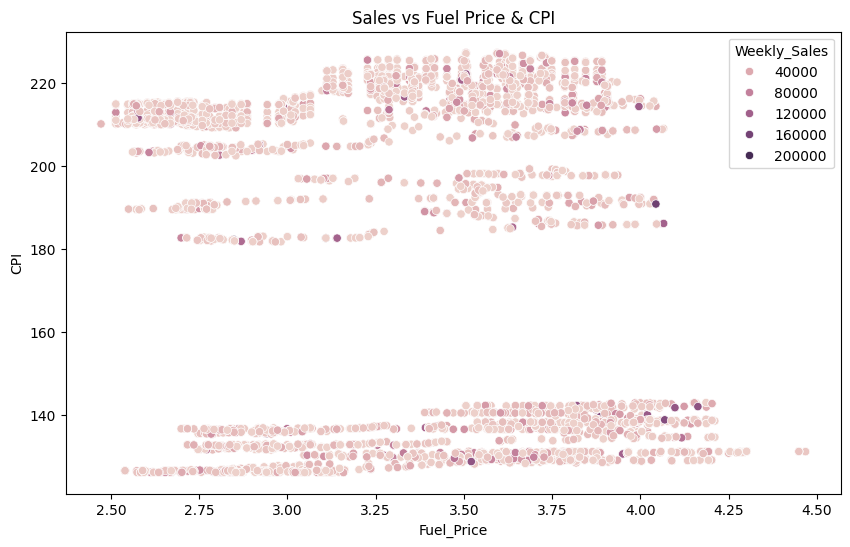

In [34]:
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x = df_sampled['Fuel_Price'], y = df_sampled['CPI'], hue = df_sampled['Weekly_Sales'])
plt.title("Sales vs Fuel Price & CPI")
plt.show()


- Sales don’t strongly correlate with Fuel Price and CPI together; relationships may be indirect.


### Treat Outliers

In [35]:
numerical_columns = df.select_dtypes(include=np.number).columns
numerical_columns

Index(['Store', 'Dept', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Size'],
      dtype='object')

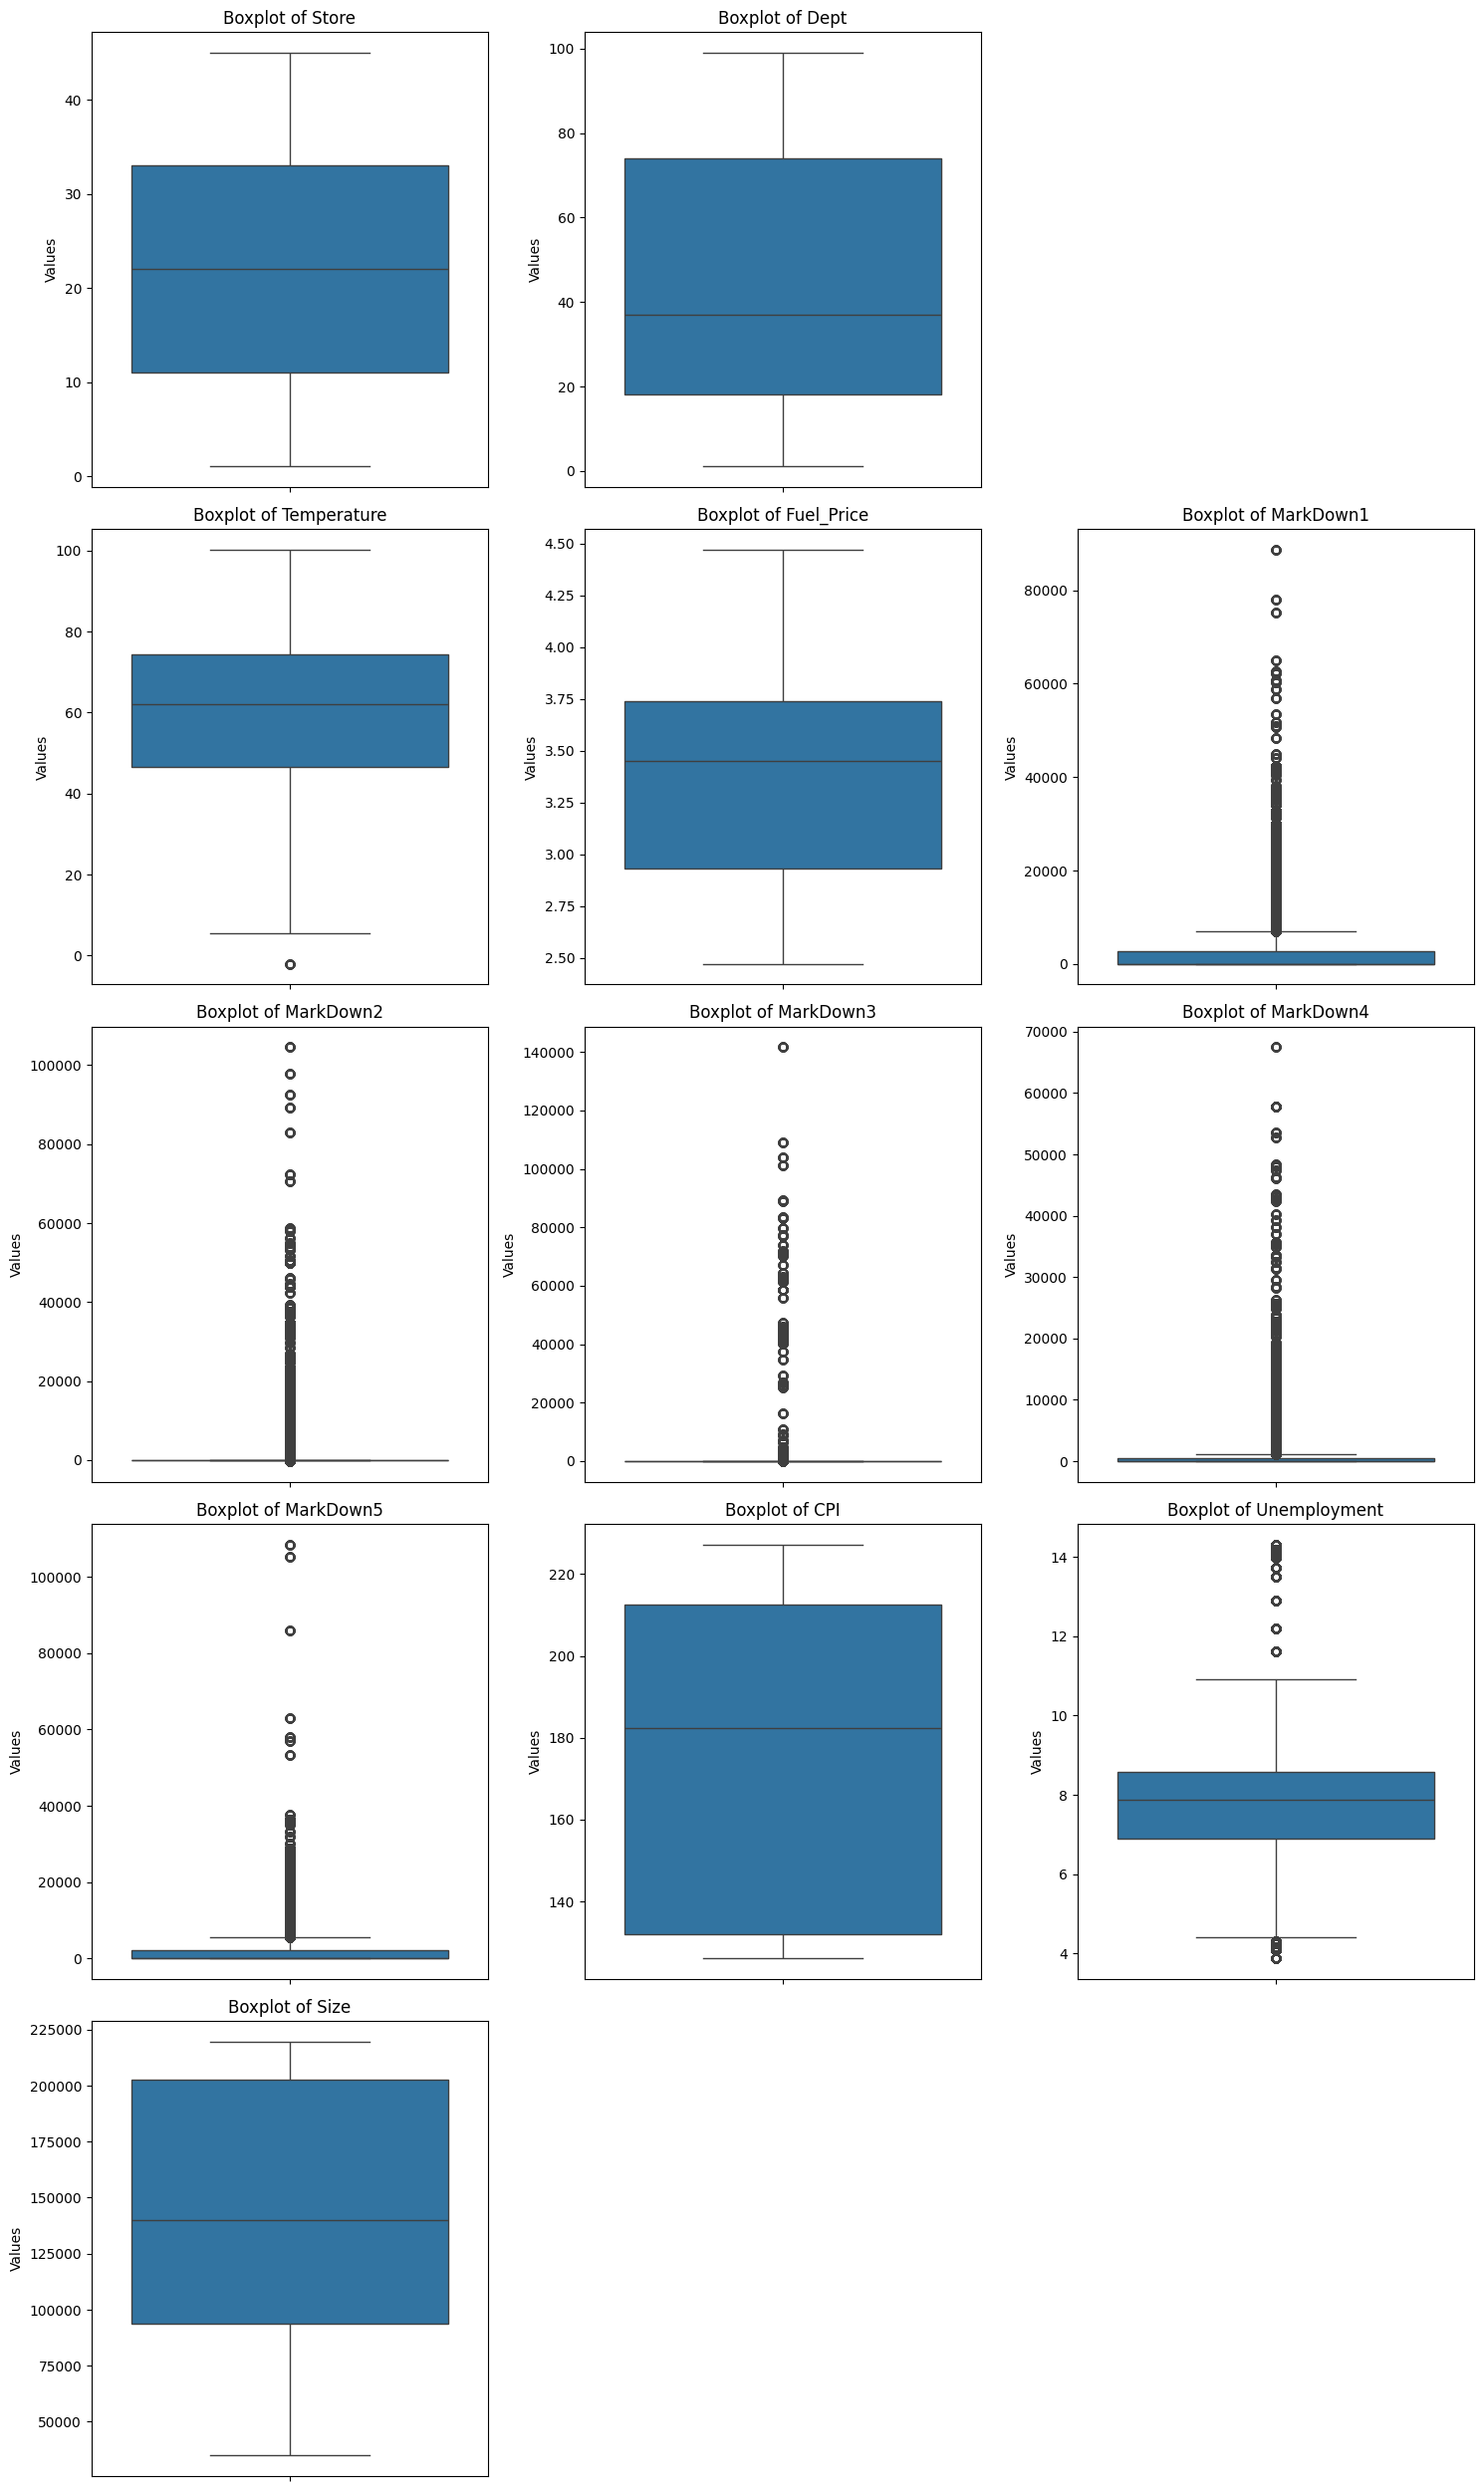

In [36]:
num_cols = len(numerical_columns)
plt.figure(figsize=(15, 5 * num_cols))
for i, col in enumerate(numerical_columns, 1):
    if col == "Weekly_Sales":
        continue
    plt.subplot(num_cols, 3, i)
    sns.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('Values')

plt.tight_layout()
plt.show()

In [37]:
for col in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']:
    df[col] = np.log1p(df[col])

- Compresses large values
- Spreads out smaller values
- Log(0) is undefined, but log1p(0) = 0

In [38]:
for col in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'Unemployment']:
    q_low = df[col].quantile(0.25)
    q_hi = df[col].quantile(0.75)
    df[col] = np.clip(df[col], q_low, q_hi)


**Remove the outliers**

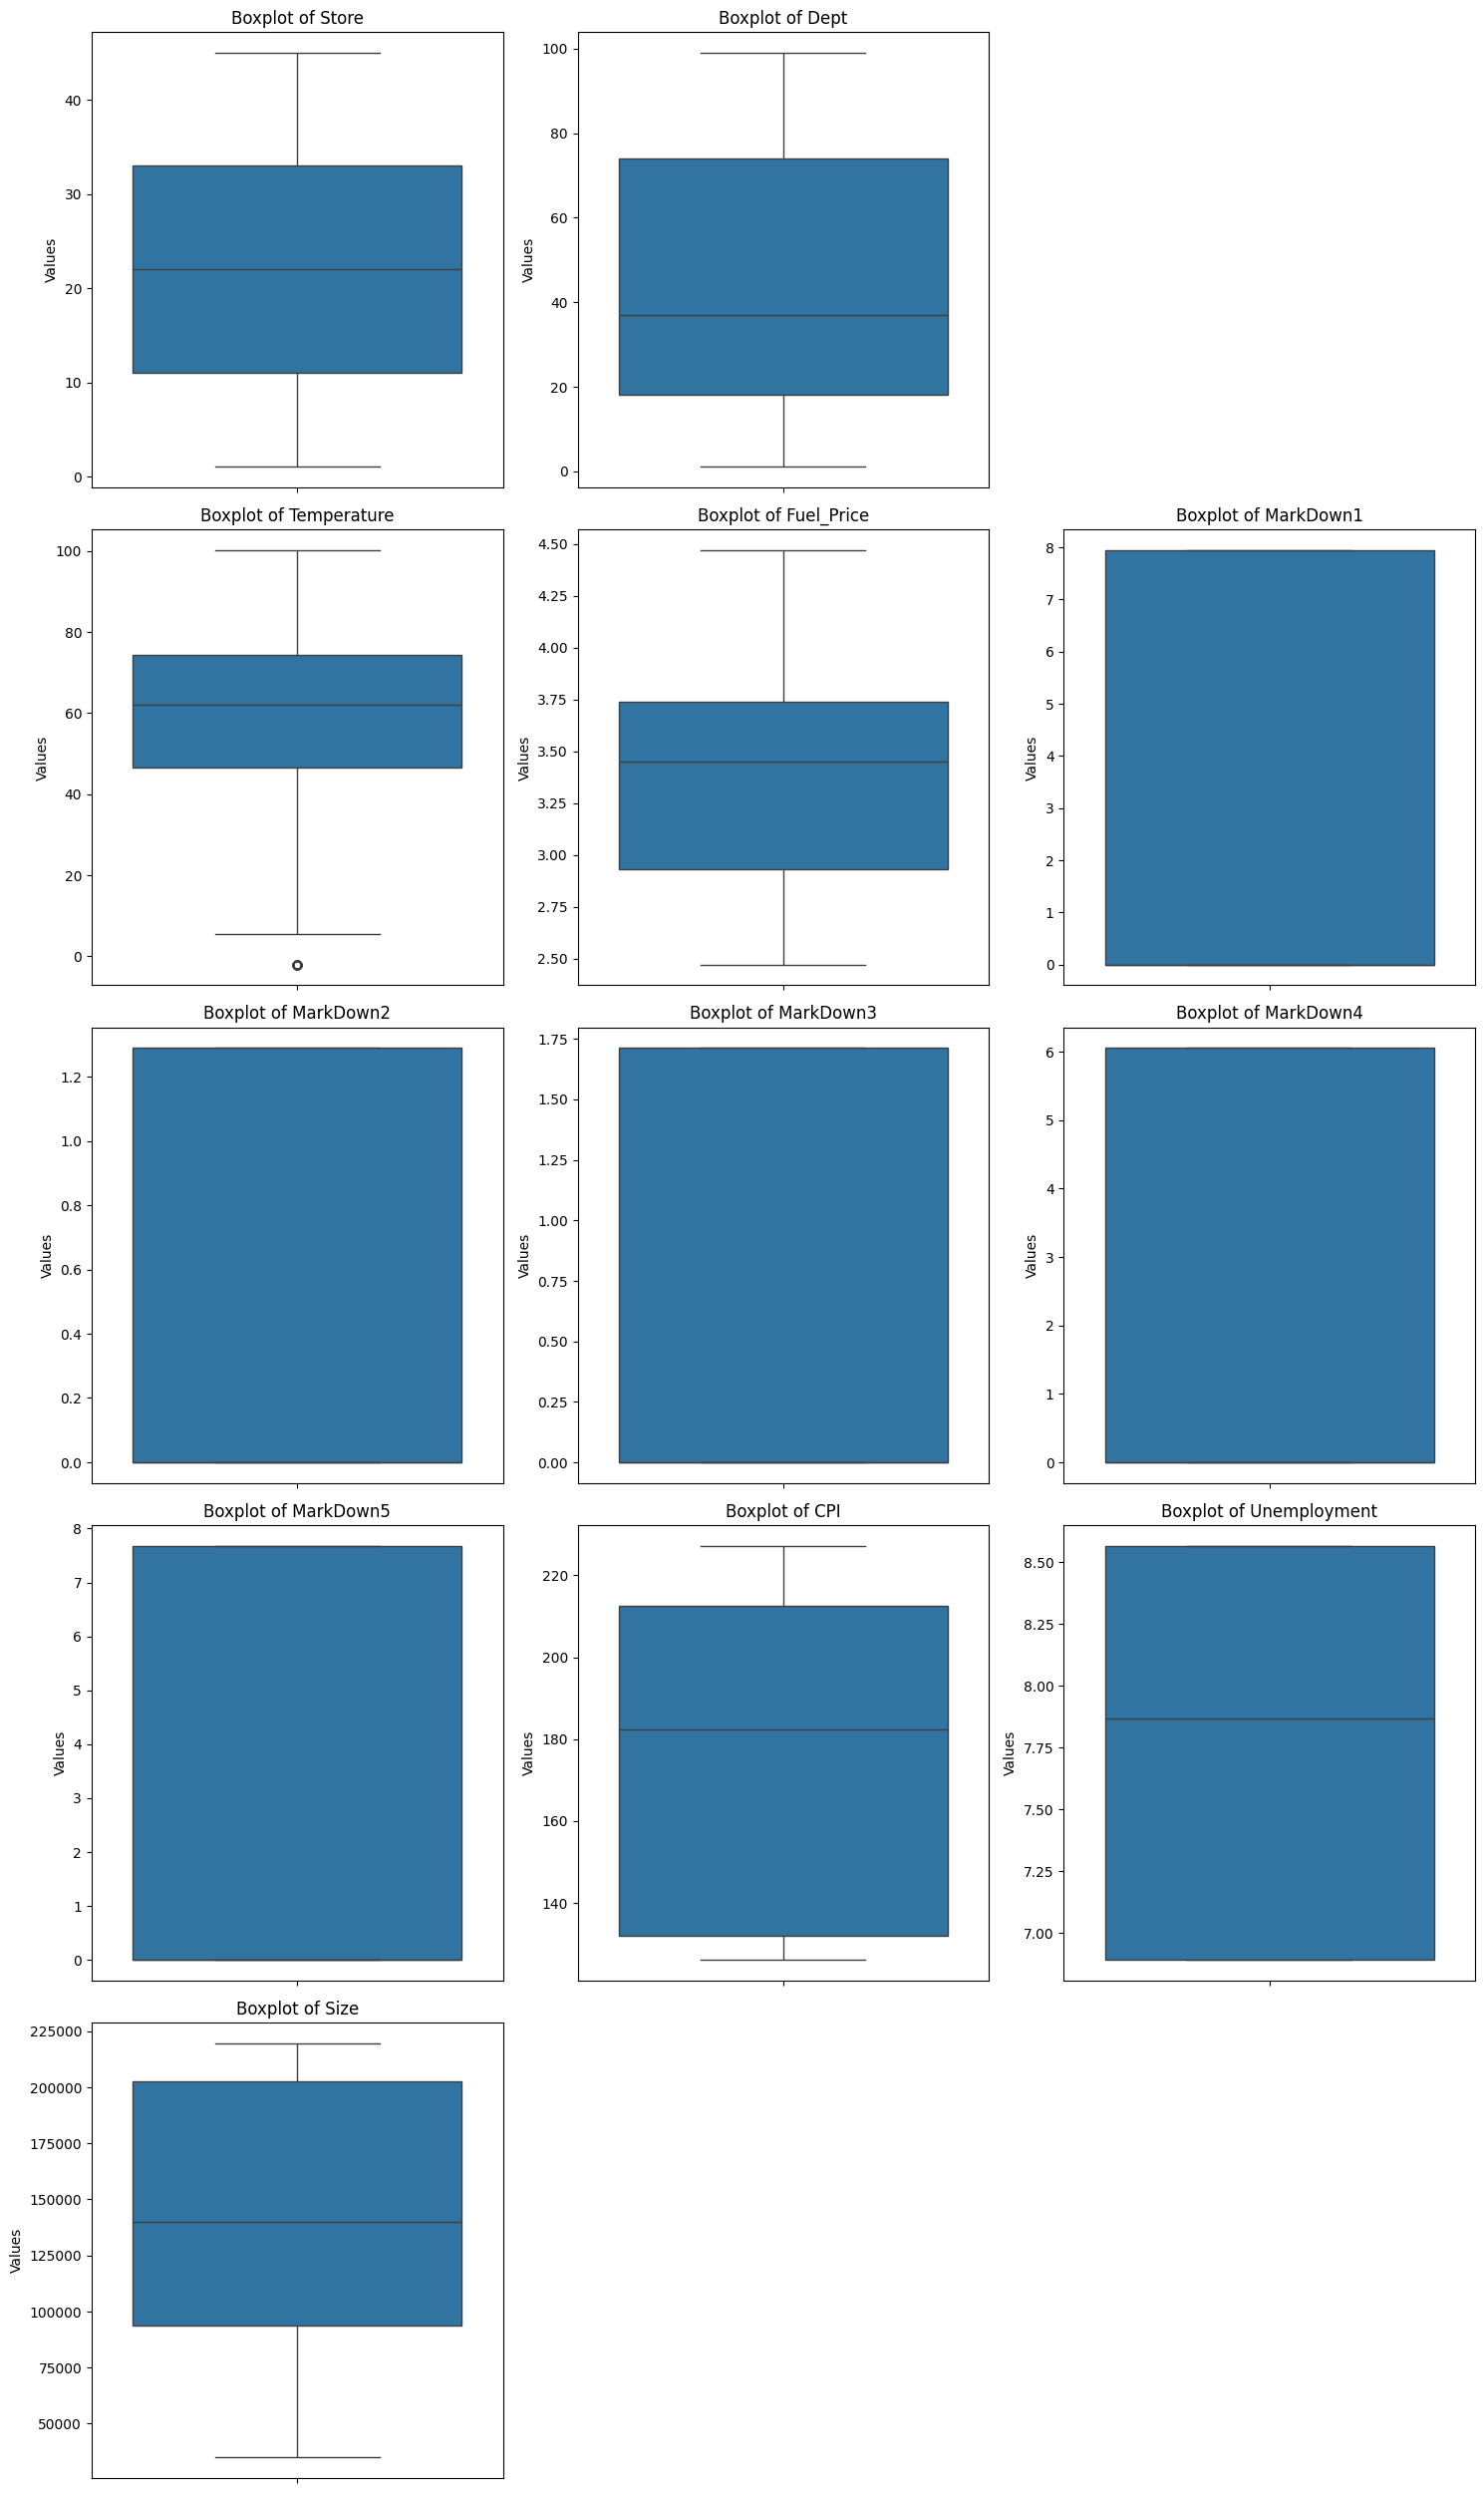

In [39]:
num_cols = len(numerical_columns)
plt.figure(figsize=(15, 5 * num_cols))
for i, col in enumerate(numerical_columns, 1):
    if col == "Weekly_Sales":
        continue
    plt.subplot(num_cols, 3, i)
    sns.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('Values')

plt.tight_layout()
plt.show()

## Feature Engineering

Create additional features such as date-based components.

In [41]:
# Extract date features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Day'] = df['Date'].dt.day

In [42]:
df.drop(['Date'], axis=1, inplace = True)

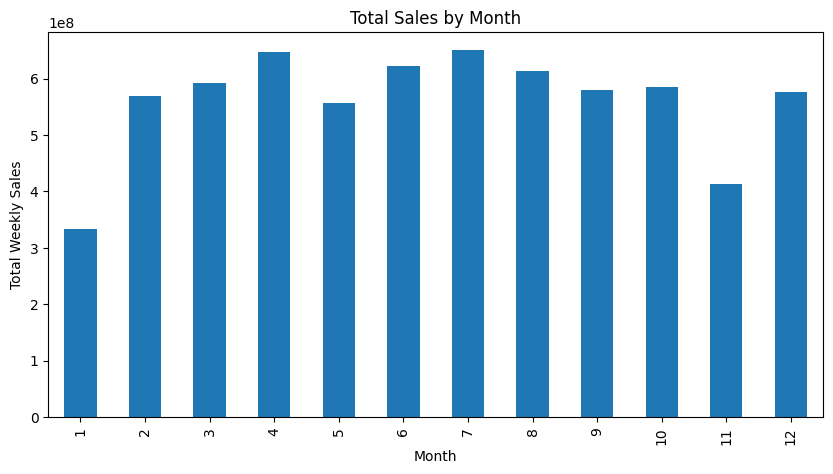

In [43]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].sum()
monthly_sales.plot(kind='bar', figsize=(10,5), title='Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Weekly Sales')
plt.show()


- Certain months may show seasonality.

## Encoding, Scaling and VIF

- **Label Encoding:** Used for `IsHoliday` and `Type` since they are categorical.
- Define the target (`Weekly_Sales`) and features
- **Standard Scaling:** Applied `StandardScaler` to normalize numerical features (`Weekly Sales`, `Temperature`, `Fuel Price`, etc.) to improve ML model performance.
- 
**VIF Calculation:**- Measures multicollinearity among numerical variables.
- High VIF values (>10) indicate strong multicollinearity, requiring feature selection.

In [44]:
n_data = df.copy()

In [45]:
n_data.head()

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Day
0,1,1,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,2010,2,5,5
1,1,1,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2010,2,6,12
2,1,1,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,2010,2,7,19
3,1,1,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,2010,2,8,26
4,1,1,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,2010,3,9,5


In [46]:
# Encoding categorical variables
label_encoder = LabelEncoder()
n_data['IsHoliday'] = label_encoder.fit_transform(n_data['IsHoliday'])
n_data['Type'] = label_encoder.fit_transform(n_data['Type'])

In [47]:
n_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 420212 entries, 0 to 421569
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         420212 non-null  int64  
 1   Dept          420212 non-null  int64  
 2   Weekly_Sales  420212 non-null  float64
 3   IsHoliday     420212 non-null  int64  
 4   Temperature   420212 non-null  float64
 5   Fuel_Price    420212 non-null  float64
 6   MarkDown1     420212 non-null  float64
 7   MarkDown2     419119 non-null  float64
 8   MarkDown3     420140 non-null  float64
 9   MarkDown4     420212 non-null  float64
 10  MarkDown5     420212 non-null  float64
 11  CPI           420212 non-null  float64
 12  Unemployment  420212 non-null  float64
 13  Type          420212 non-null  int64  
 14  Size          420212 non-null  int64  
 15  Year          420212 non-null  int32  
 16  Month         420212 non-null  int32  
 17  Week          420212 non-null  UInt32 
 18  Day      

In [55]:
n_data.drop(columns=['MarkDown2', 'MarkDown3'], inplace=True)

In [70]:
X = n_data.drop(columns=['Weekly_Sales'])
y = n_data['Weekly_Sales']

In [56]:
# sampled_data = n_data.sample(n=100000, random_state=42)  # Adjust size as needed
# X = sampled_data.drop(columns=['Weekly_Sales'])
# y = sampled_data['Weekly_Sales']

In [71]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

      Store     Dept  IsHoliday  Temperature  Fuel_Price  MarkDown1  \
0 -1.657562 -1.41734  -0.275079    -0.963831   -1.720520  -0.733319   
1 -1.657562 -1.41734   3.635321    -1.169817   -1.772863  -0.733319   
2 -1.657562 -1.41734  -0.275079    -1.092844   -1.847014  -0.733319   
3 -1.657562 -1.41734  -0.275079    -0.729657   -1.744510  -0.733319   
4 -1.657562 -1.41734  -0.275079    -0.736704   -1.604931  -0.733319   

   MarkDown4  MarkDown5       CPI  Unemployment      Type      Size     Year  \
0  -0.673283  -0.747006  1.018422      0.486075 -0.884596  0.238802 -1.21528   
1  -0.673283  -0.747006  1.022146      0.486075 -0.884596  0.238802 -1.21528   
2  -0.673283  -0.747006  1.023345      0.486075 -0.884596  0.238802 -1.21528   
3  -0.673283  -0.747006  1.024124      0.486075 -0.884596  0.238802 -1.21528   
4  -0.673283  -0.747006  1.024903      0.486075 -0.884596  0.238802 -1.21528   

      Month      Week       Day  
0 -1.371979 -1.471715 -1.219483  
1 -1.371979 -1.401056 -0

In [72]:
X_scaled.isnull().sum()

Store           0
Dept            0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
Year            0
Month           0
Week            0
Day             0
dtype: int64

In [73]:
# Calculating VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]

vif_data

,Feature,VIF
0,Store,1.242656
1,Dept,1.000778
2,IsHoliday,1.132777
3,Temperature,1.331130
4,Fuel_Price,5.553053
5,MarkDown1,80.764126
6,MarkDown4,15.331230
7,MarkDown5,48.021730
8,CPI,1.396452
9,Unemployment,1.385046


In [74]:
X_scaled.drop(['Month','Week','Day'], axis=1, inplace = True)

- Drop highly corr columns

In [75]:
# Calculating VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]

vif_data

,Feature,VIF
0,Store,1.239347
1,Dept,1.000775
2,IsHoliday,1.040887
3,Temperature,1.133662
4,Fuel_Price,3.906790
5,MarkDown1,80.421208
6,MarkDown4,15.235144
7,MarkDown5,46.188110
8,CPI,1.367521
9,Unemployment,1.340041


## 6. Model Building & Machine Learning

In this section, we build a baseline machine learning model to forecast weekly sales. We will:


- Split the data into training and testing sets
- Train a model using RandomForestregressor
- Evaluate the model performance using R²

In [76]:
# Split Data into Train & Test Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [77]:
# Train Model
rf = RandomForestRegressor(n_estimators=40, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Evaluate
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Random Forest - Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")

Random Forest - Train R²: 0.8784, Test R²: 0.8734
